# Stock Market Anomaly Detection — GME Analysis
End-to-end pipeline: data download → feature engineering → EDA → 5 anomaly detection models → comparison


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
from scipy import stats
from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.cluster import DBSCAN
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix
import warnings
warnings.filterwarnings('ignore')


## 1. Data Collection
Download GME OHLCV data from Yahoo Finance using `yfinance`.


In [2]:
import yfinance as yf

ticker     = 'GME'
start_date = '2020-01-01'
end_date   = '2023-12-31'

raw = yf.download(ticker, start_date, end_date, auto_adjust=True)

# FIX: newer yfinance returns MultiIndex columns like ("Close", "GME").
# droplevel(1) collapses them to plain names so single-column assignment works.
if isinstance(raw.columns, pd.MultiIndex):
    raw.columns = raw.columns.droplevel(1)

gme_data = raw.copy()
print(f"Downloaded {len(gme_data)} rows")
gme_data.head()


[*********************100%***********************]  1 of 1 completed

Downloaded 1006 rows


Price,Close,High,Low,Open,Volume
Date,,,,,
2020-01-02,1.5775,1.6175,1.5175,1.5350,17814400
2020-01-03,1.4700,1.5625,1.4600,1.5525,14175600
2020-01-06,1.4625,1.4775,1.4000,1.4500,13579200
2020-01-07,1.3800,1.4575,1.3600,1.4425,20912000
2020-01-08,1.4300,1.4625,1.3525,1.3725,22517600


In [3]:
gme_data.info()


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1006 entries, 2020-01-02 to 2023-12-29
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Close   1006 non-null   float64
 1   High    1006 non-null   float64
 2   Low     1006 non-null   float64
 3   Open    1006 non-null   float64
 4   Volume  1006 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 47.2 KB


## 2. Feature Engineering
We engineer 4 features from raw price data before feeding anything to a model.

| Feature | Why |
|---|---|
| Returns | Makes price stationary — models should see *change*, not level |
| Volatility | Captures nervousness; clusters in turbulent regimes |
| SMAs / MA20 | Rolling trend baseline |
| Bollinger Bands | Statistical price envelope — breakouts = anomaly candidates |
| RSI | Momentum indicator for overbought / oversold conditions |


In [4]:
# Daily log-return (pct_change gives simple return; both work)
gme_data['Returns']    = gme_data['Close'].pct_change()

# 20-day rolling volatility (std of returns)
gme_data['Volatility'] = gme_data['Returns'].rolling(window=20).std()

# Simple Moving Averages
gme_data['SMA_10'] = gme_data['Close'].rolling(window=10).mean()
gme_data['SMA_20'] = gme_data['Close'].rolling(window=20).mean()
gme_data['SMA_50'] = gme_data['Close'].rolling(window=50).mean()

# RSI (14-period)
def calculate_rsi(series, periods=14):
    delta = series.diff()
    gain  = delta.where(delta > 0, 0).rolling(window=periods).mean()
    loss  = (-delta.where(delta < 0, 0)).rolling(window=periods).mean()
    rs    = gain / loss
    return 100 - (100 / (1 + rs))

gme_data['RSI'] = calculate_rsi(gme_data['Close'])

# Bollinger Bands
# FIX: compute rolling_std as a plain Series FIRST, then assign.
# Doing the rolling call inline inside [] tries to assign a DataFrame → error.
rolling_std        = gme_data['Close'].rolling(window=20).std()
gme_data['Upper_BB'] = gme_data['SMA_20'] + (rolling_std * 2)
gme_data['Lower_BB'] = gme_data['SMA_20'] - (rolling_std * 2)

# Drop rows where any feature is NaN (caused by rolling windows at the start)
gme_data = gme_data.dropna()
print(f"Clean dataset: {len(gme_data)} rows")
gme_data.head()


Clean dataset: 957 rows


Price,Close,High,Low,Open,Volume,Returns,Volatility,SMA_10,SMA_20,SMA_50,RSI,Upper_BB,Lower_BB
Date,,,,,,,,,,,,,
2020-03-13,1.1475,1.1625,0.9625,1.0325,23148800,0.153266,0.062151,0.99375,0.973500,1.08575,65.187717,1.121170,0.825830
2020-03-16,1.0925,1.1425,0.9750,0.9825,19466800,-0.047930,0.063061,1.00725,0.977875,1.07605,63.455150,1.134394,0.821356
2020-03-17,1.0575,1.1625,1.0275,1.1000,14248800,-0.032037,0.063618,1.02225,0.980000,1.06780,64.093959,1.139761,0.820239
2020-03-18,0.9425,1.0625,0.8750,1.0250,14606800,-0.108747,0.068209,1.02225,0.975250,1.05740,54.464285,1.133455,0.817045
2020-03-19,1.0475,1.0500,0.8875,0.9275,20158000,0.111406,0.072822,1.02800,0.975875,1.05075,58.082194,1.135168,0.816582


## 3. Exploratory Data Analysis (EDA)


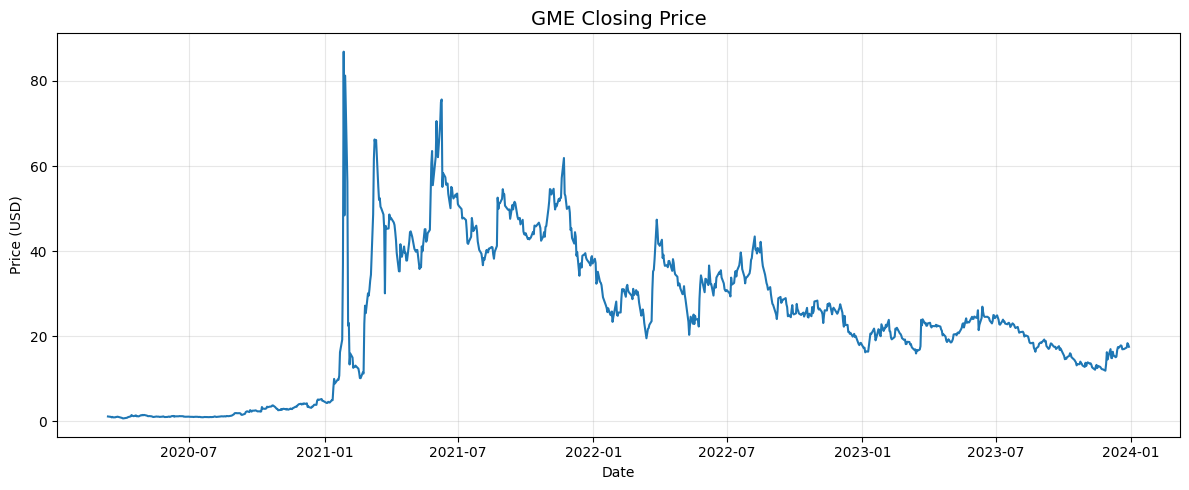

In [5]:
plt.figure(figsize=(12, 5))
plt.plot(gme_data.index, gme_data['Close'], lw=1.5)
plt.title(f'{ticker} Closing Price', fontsize=14)
plt.xlabel('Date'); plt.ylabel('Price (USD)')
plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()


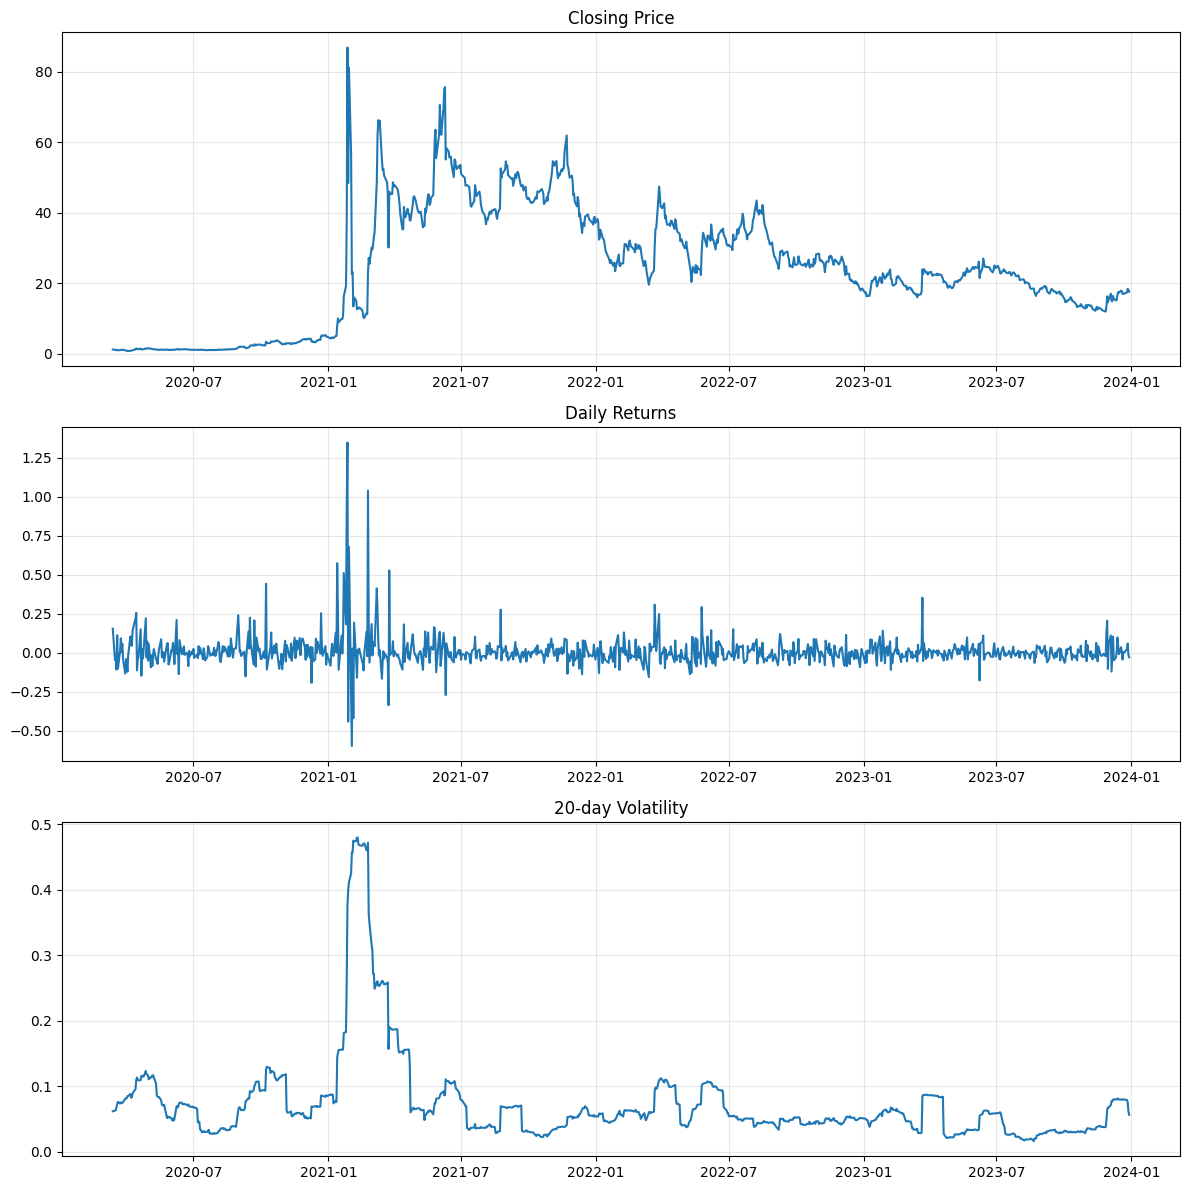

In [6]:
fig, axes = plt.subplots(3, 1, figsize=(12, 12))
axes[0].plot(gme_data.index, gme_data['Close']);   axes[0].set_title('Closing Price')
axes[1].plot(gme_data.index, gme_data['Returns']); axes[1].set_title('Daily Returns')
axes[2].plot(gme_data.index, gme_data['Volatility']); axes[2].set_title('20-day Volatility')
for ax in axes:
    ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()


In [7]:
fig = go.Figure()
fig.add_trace(go.Scatter(x=gme_data.index, y=gme_data['Close'],    name='Close',    line=dict(color='blue', width=2)))
fig.add_trace(go.Scatter(x=gme_data.index, y=gme_data['SMA_10'],   name='SMA 10',   line=dict(color='green', width=1.5, dash='dot')))
fig.add_trace(go.Scatter(x=gme_data.index, y=gme_data['SMA_50'],   name='SMA 50',   line=dict(color='orange', width=1.5, dash='dash')))
fig.add_trace(go.Scatter(x=gme_data.index, y=gme_data['Upper_BB'], name='Upper BB', line=dict(color='red', width=1, dash='dot')))
fig.add_trace(go.Scatter(x=gme_data.index, y=gme_data['Lower_BB'], name='Lower BB', line=dict(color='purple', width=1, dash='dot')))
fig.update_layout(title='GME — Price with Technical Indicators', xaxis_title='Date',
                  yaxis_title='Price', width=1100, height=500)
fig.show()


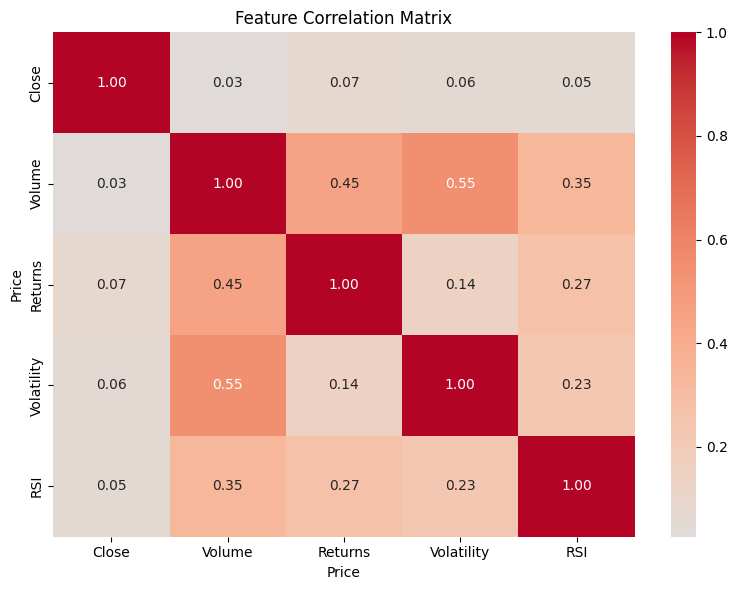

In [8]:
corr = gme_data[['Close','Volume','Returns','Volatility','RSI']].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Feature Correlation Matrix')
plt.tight_layout(); plt.show()


## 4. Anomaly Detection — Method 1: Z-Score

**What it is:** Measures how many standard deviations a value is from the mean.
$$Z_t = \frac{|P_t - \mu|}{\sigma}$$
If Z > 3 → the price is in the outermost 0.3% of the distribution → flag as anomaly.

**Simple analogy:** Average human height is 5'7". Someone who is 7'5" has a very high Z-score — they are a statistical outlier.

**Limitation here:** Applied to raw Close price, not returns. So a genuine bull-run can get flagged simply because prices are "high", even if daily moves are normal.


In [9]:
gme_data['Close_Z_Score'] = stats.zscore(gme_data['Close'])
anomalies_zscore = gme_data[abs(gme_data['Close_Z_Score']) > 3]
print(f"Z-Score anomalies: {len(anomalies_zscore)}")
anomalies_zscore[['Close','Close_Z_Score']].head(10)


Z-Score anomalies: 4


Price,Close,Close_Z_Score
Date,,
2021-01-27,86.877502,3.777633
2021-01-29,81.250000,3.437459
2021-06-08,75.000000,3.059656
2021-06-09,75.639999,3.098343


In [10]:
fig = go.Figure()
fig.add_trace(go.Scatter(x=gme_data.index, y=gme_data['Close'], mode='lines',
                         name='Close Price', line=dict(color='blue', width=2)))
fig.add_trace(go.Scatter(x=anomalies_zscore.index, y=anomalies_zscore['Close'],
                         mode='markers', name='Z-Score Anomaly',
                         marker=dict(color='red', size=10, symbol='circle')))
fig.update_layout(title='GME — Z-Score Anomalies', xaxis_title='Date',
                  yaxis_title='Price', width=1100, height=450)
fig.show()


## 5. Anomaly Detection — Method 2: Isolation Forest

**What it is:** Tree-based ML algorithm. Builds many random trees that split the feature space. Anomalies get *isolated* in very few splits because they are far from the dense cluster.

**Simple analogy:** In a crowd of 1000 people, one person stands completely alone in a field. You only need 2 random dividing lines to isolate them. Isolating someone in the middle of the crowd takes 20+ lines.

**Anomaly score:** Short path length (few splits) → more anomalous. Score near −1 = anomaly.

**Advantage over Z-Score:** Uses ALL 4 features simultaneously — Close, Volume, Returns, Volatility.


In [11]:
features = ['Close', 'Volume', 'Returns', 'Volatility']

scaler = StandardScaler()
X = scaler.fit_transform(gme_data[features])

iso_forest = IsolationForest(contamination=0.01, random_state=42)
gme_data['Anomaly_IsoForest'] = iso_forest.fit_predict(X)

anomalies_iso = gme_data[gme_data['Anomaly_IsoForest'] == -1]
print(f"Isolation Forest anomalies: {len(anomalies_iso)}")


Isolation Forest anomalies: 10


In [12]:
fig = go.Figure()
fig.add_trace(go.Scatter(x=gme_data.index, y=gme_data['Close'], mode='lines',
                         name='Close Price', line=dict(color='blue', width=2)))
fig.add_trace(go.Scatter(x=anomalies_iso.index, y=anomalies_iso['Close'],
                         mode='markers', name='Isolation Forest Anomaly',
                         marker=dict(color='red', size=10, symbol='circle')))
fig.update_layout(title='GME — Isolation Forest Anomalies', xaxis_title='Date',
                  yaxis_title='Price', width=1100, height=450)
fig.show()


## 6. Anomaly Detection — Method 3: DBSCAN

**What it is:** Density-Based Spatial Clustering. Groups data points that are close together (dense regions = clusters). Points that don't belong to any cluster are labelled **noise** (= anomaly).

**Simple analogy:** Imagine plotting all trading days as dots on a graph (x = return, y = volume). Normal days cluster tightly. The GME short-squeeze days are lone dots far from any cluster — DBSCAN labels them as noise.

**Key parameters:**
- `eps` = the radius to look for neighbours. Bigger → more points join clusters (fewer anomalies).
- `min_samples` = how many neighbours needed to be a "core point". Bigger → harder to form clusters (more anomalies).


In [13]:
# X is already StandardScaler-transformed from the Isolation Forest step
dbscan = DBSCAN(eps=0.5, min_samples=5)
gme_data['Anomaly_DBSCAN'] = dbscan.fit_predict(X)

anomalies_dbscan = gme_data[gme_data['Anomaly_DBSCAN'] == -1]
print(f"DBSCAN anomalies: {len(anomalies_dbscan)}")
print(f"Clusters found: {gme_data['Anomaly_DBSCAN'].nunique() - 1}")  # -1 excludes noise label


DBSCAN anomalies: 101
Clusters found: 2


In [14]:
# Scatter plot: Close vs Volume, coloured by cluster label
gme_data['Color_DBSCAN'] = gme_data['Anomaly_DBSCAN'].apply(
    lambda x: 'Anomaly (noise)' if x == -1 else 'Normal'
)
fig = px.scatter(gme_data, x='Close', y='Volume', color='Color_DBSCAN',
                 color_discrete_map={'Anomaly (noise)': 'red', 'Normal': 'steelblue'},
                 title='DBSCAN — Close vs Volume (red = anomaly/noise)',
                 hover_data=['Returns', 'Volatility'], width=1000, height=500)
fig.show()


In [15]:
fig = go.Figure()
fig.add_trace(go.Scatter(x=gme_data.index, y=gme_data['Close'], mode='lines',
                         name='Close Price', line=dict(color='blue', width=2)))
fig.add_trace(go.Scatter(x=anomalies_dbscan.index, y=anomalies_dbscan['Close'],
                         mode='markers', name='DBSCAN Anomaly',
                         marker=dict(color='red', size=10, symbol='diamond')))
fig.update_layout(title='GME — DBSCAN Anomalies (time series)', xaxis_title='Date',
                  yaxis_title='Price', width=1100, height=450)
fig.show()


## 7. Anomaly Detection — Method 4: LSTM Neural Network

**What it is:** A recurrent deep learning model that *remembers* past time steps. Trained to predict the next day's features given the last 20 days. Anomaly = day where prediction error is very high.

**Simple analogy:** You've watched 1000 cricket matches and learned the pattern of how scores progress. Suddenly a batsman hits 6 sixes in an over — your internal "prediction" is way off. That's an anomaly.

**Why better than Z-Score for finance:** Finance is sequential — today's behaviour depends on yesterday's. LSTM explicitly captures this. Z-Score and IF treat each day as independent.

**Architecture:**
```
Input: 20 days × 4 features
       ↓
LSTM (50 units, ReLU)
       ↓
Dense (4 outputs = next day prediction)

Anomaly score = MSE between actual and predicted
```


In [16]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.optimizers import Adam

sequence_length = 20

# Scale features
scaler_lstm = StandardScaler()
normalized_data = scaler_lstm.fit_transform(gme_data[features])

# FIX: original notebook had a bug — create_sequence returned X but referenced
# undeclared variable 'y'. Fixed: both X and Y built inside the function.
def create_sequences(data, seq_len):
    X, Y = [], []
    for i in range(len(data) - seq_len):
        X.append(data[i : i + seq_len])
        Y.append(data[i + seq_len])
    return np.array(X), np.array(Y)

X_seq, y_seq = create_sequences(normalized_data, sequence_length)
print(f"Sequence shapes — X: {X_seq.shape}, y: {y_seq.shape}")

# Train / test split (80/20)
train_size = int(len(X_seq) * 0.8)
X_train, X_test = X_seq[:train_size], X_seq[train_size:]
y_train, y_test = y_seq[:train_size], y_seq[train_size:]


Sequence shapes — X: (937, 20, 4), y: (937, 4)


In [17]:
model_lstm = Sequential([
    LSTM(50, activation='relu', input_shape=(sequence_length, len(features))),
    Dense(len(features))
])
model_lstm.compile(optimizer=Adam(learning_rate=0.001), loss='mse')

history_lstm = model_lstm.fit(
    X_train, y_train,
    epochs=50, batch_size=32,
    validation_split=0.1,
    shuffle=False, verbose=0
)
print("LSTM training complete")


LSTM training complete


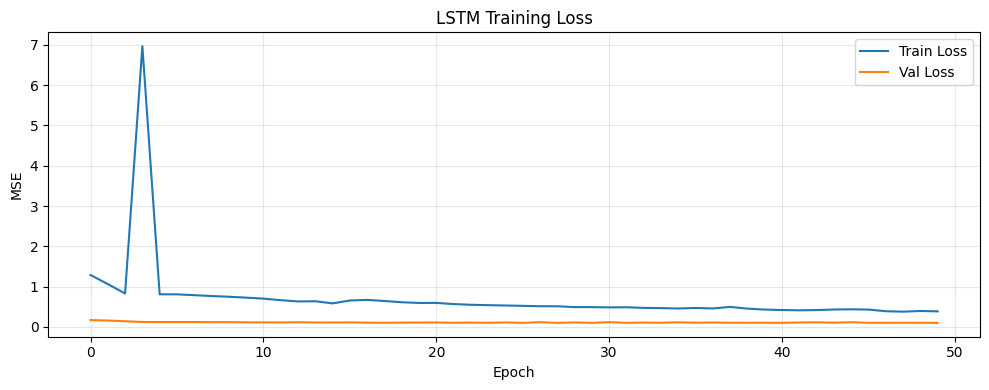

In [18]:
plt.figure(figsize=(10, 4))
plt.plot(history_lstm.history['loss'],     label='Train Loss')
plt.plot(history_lstm.history['val_loss'], label='Val Loss')
plt.title('LSTM Training Loss'); plt.xlabel('Epoch'); plt.ylabel('MSE')
plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()


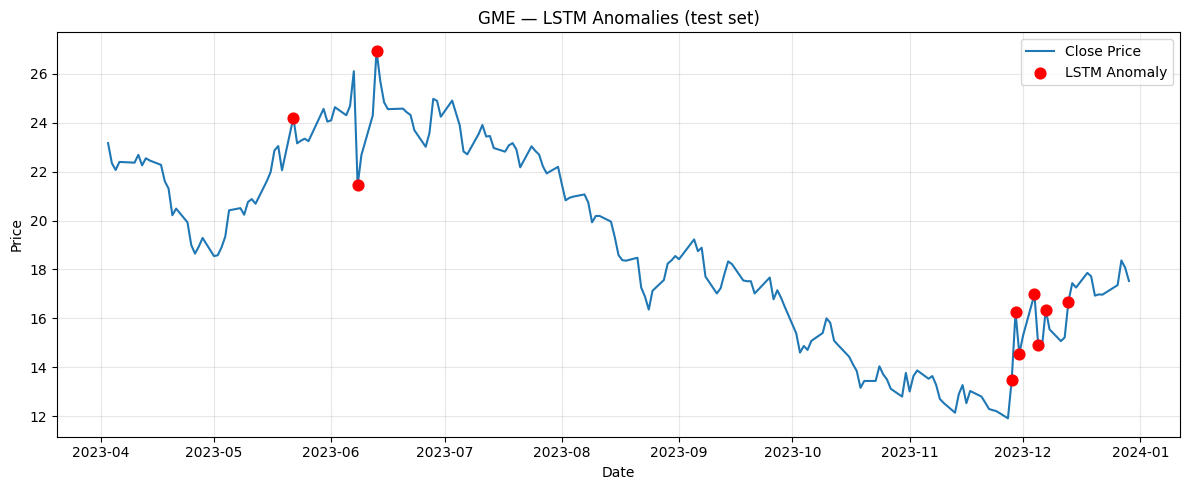

LSTM anomalies detected: 10


In [19]:
y_pred_lstm = model_lstm.predict(X_test, verbose=0)
mse_lstm    = np.mean(np.power(y_test - y_pred_lstm, 2), axis=1)
threshold_lstm = np.percentile(mse_lstm, 95)
anomalies_lstm = mse_lstm > threshold_lstm

# Map back to original DataFrame index (test portion only)
test_index = gme_data.index[train_size + sequence_length:]

plt.figure(figsize=(12, 5))
plt.plot(test_index, gme_data['Close'][train_size + sequence_length:], label='Close Price', lw=1.5)
plt.scatter(test_index[anomalies_lstm],
            gme_data['Close'][train_size + sequence_length:][anomalies_lstm],
            color='red', s=60, label='LSTM Anomaly', zorder=5)
plt.title('GME — LSTM Anomalies (test set)')
plt.xlabel('Date'); plt.ylabel('Price')
plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

print(f"LSTM anomalies detected: {anomalies_lstm.sum()}")


## 8. Anomaly Detection — Method 5: Autoencoder

**What it is:** A neural network that learns to *compress* normal patterns into 2 numbers (bottleneck), then *reconstruct* them back. When an anomalous day passes through, the reconstruction fails (high MSE = anomaly).

**Simple analogy:** You're really good at summarising Bollywood movies in 2 words. Normal movies: easy. Now someone gives you *Inception*. Your 2-word summary is terrible — the reconstruction error is high.

**Architecture:**
```
Input (4 features)
  → Dense(8) → Dense(4) → Dense(2)   ← ENCODER
                              ↓
                       Bottleneck (2D latent space)
                              ↓
  Dense(4) → Dense(8) → Dense(4)     ← DECODER
                              ↓
                   Reconstructed input
```
Loss = MSE(original, reconstructed). High loss on a test day → anomaly.


In [20]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense

# Scale
scaler_ae   = StandardScaler()
scaled_ae   = scaler_ae.fit_transform(gme_data[features])

train_size_ae = int(len(scaled_ae) * 0.8)
train_ae  = scaled_ae[:train_size_ae]

input_dim    = scaled_ae.shape[1]   # 4
encoding_dim = 2                    # bottleneck

inp = Input(shape=(input_dim,))
enc = Dense(8,  activation='relu')(inp)
enc = Dense(4,  activation='relu')(enc)
enc = Dense(encoding_dim, activation='relu')(enc)
dec = Dense(4,  activation='relu')(enc)
dec = Dense(8,  activation='relu')(dec)
out = Dense(input_dim, activation='linear')(dec)

autoencoder = Model(inputs=inp, outputs=out)
autoencoder.compile(optimizer=Adam(learning_rate=0.001), loss='mse')

history_ae = autoencoder.fit(
    train_ae, train_ae,
    epochs=100, batch_size=32,
    shuffle=True, validation_split=0.2, verbose=0
)
print("Autoencoder training complete")


Autoencoder training complete


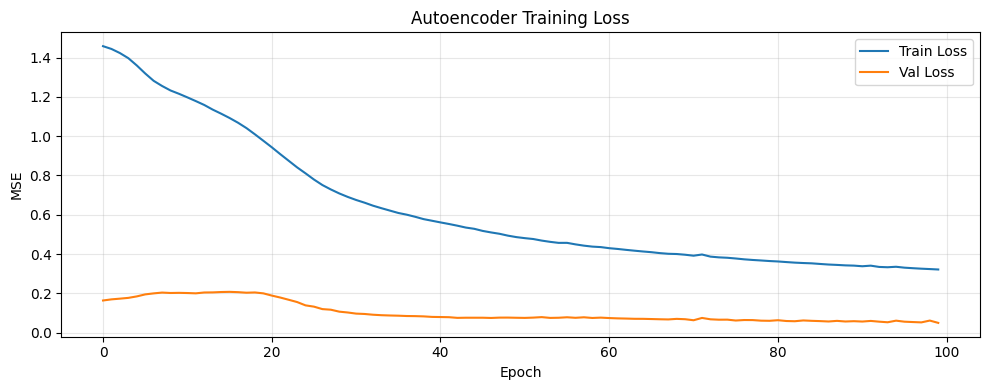

In [21]:
plt.figure(figsize=(10, 4))
plt.plot(history_ae.history['loss'],     label='Train Loss')
plt.plot(history_ae.history['val_loss'], label='Val Loss')
plt.title('Autoencoder Training Loss'); plt.xlabel('Epoch'); plt.ylabel('MSE')
plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()


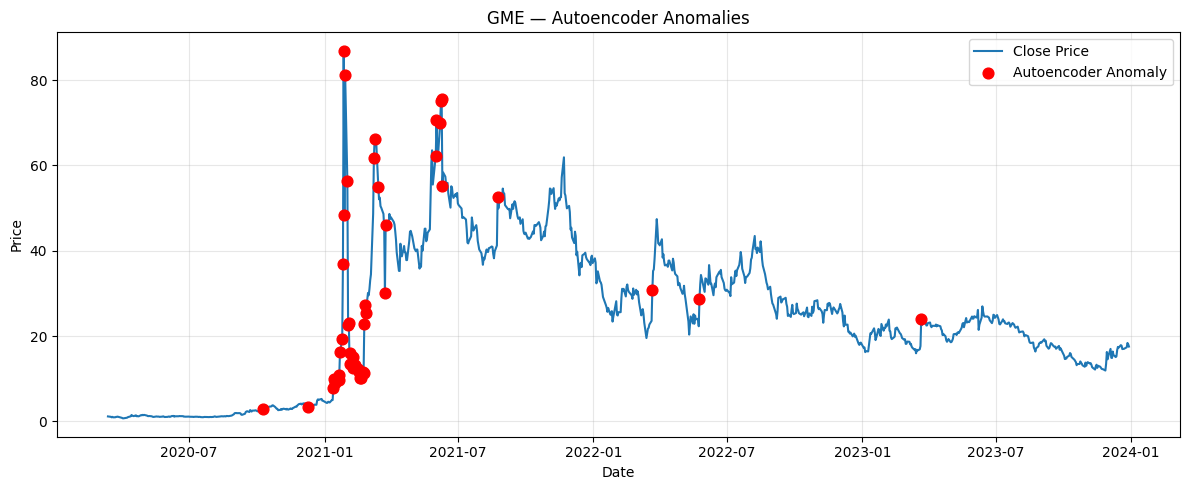

Autoencoder anomalies: 48


In [22]:
preds_ae       = autoencoder.predict(scaled_ae, verbose=0)
mse_ae         = np.mean(np.power(scaled_ae - preds_ae, 2), axis=1)
threshold_ae   = np.percentile(mse_ae, 95)
anomalies_ae   = mse_ae > threshold_ae

gme_data['Anomaly_Autoencoder'] = anomalies_ae.astype(int)

plt.figure(figsize=(12, 5))
plt.plot(gme_data.index, gme_data['Close'], lw=1.5, label='Close Price')
plt.scatter(gme_data.index[anomalies_ae],
            gme_data['Close'][anomalies_ae],
            color='red', s=60, label='Autoencoder Anomaly', zorder=5)
plt.title('GME — Autoencoder Anomalies')
plt.xlabel('Date'); plt.ylabel('Price')
plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

print(f"Autoencoder anomalies: {anomalies_ae.sum()}")


## 9. Combined Anomaly View + Model Comparison

Now we overlay all 5 methods on one chart and compute comparison metrics.

Since we have no ground-truth labels, we use a **combined anomaly column** (flagged by *any* method) as proxy ground truth, then measure precision / recall / F1 of each individual method against it.


In [23]:
# Build combined_anomaly = flagged by AT LEAST ONE method
gme_data['Combined_Anomaly'] = (
    (abs(gme_data['Close_Z_Score']) > 3)       |
    (gme_data['Anomaly_IsoForest'] == -1)       |
    (gme_data['Anomaly_DBSCAN']    == -1)       |
    (gme_data['Anomaly_Autoencoder'] == 1)
).astype(int)

print(f"Days flagged by at least one model: {gme_data['Combined_Anomaly'].sum()}")


Days flagged by at least one model: 101


In [24]:
fig = go.Figure()
fig.add_trace(go.Scatter(x=gme_data.index, y=gme_data['Close'],
                         mode='lines', name='Close Price', line=dict(color='black', width=1.5)))

overlays = [
    (abs(gme_data['Close_Z_Score']) > 3, 'Z-Score',          'red',    'circle'),
    (gme_data['Anomaly_IsoForest'] == -1,'Isolation Forest', 'green',  'square'),
    (gme_data['Anomaly_DBSCAN']    == -1,'DBSCAN',           'blue',   'diamond'),
    (gme_data['Anomaly_Autoencoder']==1, 'Autoencoder',      'orange', 'star'),
]
for mask, name, color, symbol in overlays:
    fig.add_trace(go.Scatter(
        x=gme_data.index[mask], y=gme_data['Close'][mask],
        mode='markers', name=name,
        marker=dict(color=color, size=9, symbol=symbol)
    ))

fig.update_layout(title='GME — All Models Combined Overlay',
                  xaxis_title='Date', yaxis_title='Price', width=1200, height=550)
fig.show()


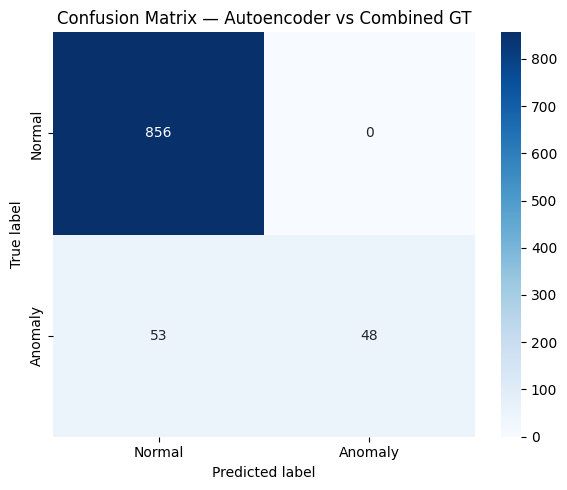

In [25]:
# Confusion matrix for Autoencoder vs combined ground truth
cm = confusion_matrix(gme_data['Combined_Anomaly'], gme_data['Anomaly_Autoencoder'])
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal','Anomaly'], yticklabels=['Normal','Anomaly'])
plt.title('Confusion Matrix — Autoencoder vs Combined GT')
plt.ylabel('True label'); plt.xlabel('Predicted label')
plt.tight_layout(); plt.show()


In [26]:
# FIX: original notebook had incomplete loop and referenced undefined variables.
# Full, clean comparison loop:

method_preds = {
    'Z_Score':         (abs(gme_data['Close_Z_Score']) > 3).astype(int),
    'IsoForest':       (gme_data['Anomaly_IsoForest'] == -1).astype(int),
    'DBSCAN':          (gme_data['Anomaly_DBSCAN']    == -1).astype(int),
    'Autoencoder':     gme_data['Anomaly_Autoencoder'],
}

results = []
for method, preds in method_preds.items():
    p = precision_score(gme_data['Combined_Anomaly'], preds, zero_division=0)
    r = recall_score(   gme_data['Combined_Anomaly'], preds, zero_division=0)
    f = f1_score(       gme_data['Combined_Anomaly'], preds, zero_division=0)
    results.append({'Method': method, 'Precision': round(p, 3),
                    'Recall': round(r, 3), 'F1-Score': round(f, 3)})

results_df = pd.DataFrame(results)
print("\nModel Comparison (vs combined ground truth):")
print(results_df.to_string(index=False))



Model Comparison (vs combined ground truth):
     Method  Precision  Recall  F1-Score
    Z_Score        1.0   0.040     0.076
  IsoForest        1.0   0.099     0.180
     DBSCAN        1.0   1.000     1.000
Autoencoder        1.0   0.475     0.644


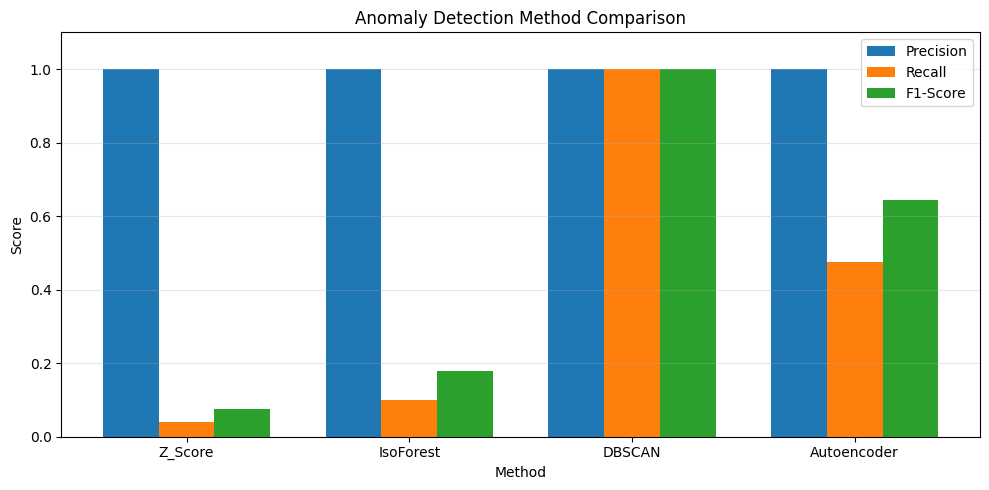

In [27]:
methods = results_df['Method'].tolist()
x = np.arange(len(methods))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - width, results_df['Precision'], width, label='Precision')
ax.bar(x,          results_df['Recall'],   width, label='Recall')
ax.bar(x + width,  results_df['F1-Score'], width, label='F1-Score')
ax.set_xlabel('Method'); ax.set_ylabel('Score')
ax.set_title('Anomaly Detection Method Comparison')
ax.set_xticks(x); ax.set_xticklabels(methods)
ax.legend(); ax.set_ylim(0, 1.1)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout(); plt.show()


In [28]:
print("=" * 50)
print("ANOMALY COUNT SUMMARY")
print("=" * 50)
print(f"Z-Score:          {(abs(gme_data['Close_Z_Score']) > 3).sum()}")
print(f"Isolation Forest: {(gme_data['Anomaly_IsoForest'] == -1).sum()}")
print(f"DBSCAN:           {(gme_data['Anomaly_DBSCAN']    == -1).sum()}")
print(f"Autoencoder:      {gme_data['Anomaly_Autoencoder'].sum()}")
print(f"Combined (any):   {gme_data['Combined_Anomaly'].sum()}")
print(f"Total trading days: {len(gme_data)}")


ANOMALY COUNT SUMMARY
Z-Score:          4
Isolation Forest: 10
DBSCAN:           101
Autoencoder:      48
Combined (any):   101
Total trading days: 957
